In [ ]:
from pathlib import Path
from collections import Counter
import os
import random
import numpy as np
import torch

PROJECT_DIR = Path.cwd()
SENSOR_DATA_DIR = PROJECT_DIR / "CREMA_D_Test"
OUTPUT_DIR = PROJECT_DIR / "Model_Output_CREMA_Retrained"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Actor-independent evaluation
DEVELOPMENT_ACTORS = [
    "1016",
    "1020",
    "1034",
    "1050",
]

TEST_ACTORS = [
    "1067",
    "1087",
]

CLASS_NAMES={
    0:"calm_speech",
    1:"distress",
}

CLASS_LABELS = {
    class_name: class_id
    for class_id, class_name in CLASS_NAMES.items()}

N_CLASSES = 2
SENSOR_SAMPLE_RATE = 8000

BANDPASS_LOW_HZ = 80
BANDPASS_HIGH_HZ = min(
    2000,
    int(SENSOR_SAMPLE_RATE * 0.45),
)

WINDOW_SEC = 3
HOP_SEC = 1.0
FEATURE_TYPE = "mfcc"

N_MFCC = 40
N_FFT = 512
HOP_LENGTH = 256
N_FEATURES = N_MFCC * 3 + 2

# Reproducibility and device
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

required_folders = [
    "calm_speech",
    "distress",
]

for class_name in required_folders:
    class_folder = SENSOR_DATA_DIR / class_name

    if not class_folder.exists():
        raise FileNotFoundError(
            f"Missing class folder: {class_folder}"
        )


print("CREMA-D RETRAINING")

print(f"Dataset: {SENSOR_DATA_DIR}")
print(f"Output:  {OUTPUT_DIR}")
print(f"Device:  {DEVICE}")
print(f"Sample rate: {SENSOR_SAMPLE_RATE} Hz")
print(f"Window: {WINDOW_SEC} seconds")
print(f"Hop: {HOP_SEC} seconds")
print(f"Feature type: {FEATURE_TYPE}")

print("\nDevelopment actors:")
print(DEVELOPMENT_ACTORS)

print("\nUntouched test actors:")
print(TEST_ACTORS)
print("\nPrepared file counts:")

for class_name in required_folders:
    class_folder = SENSOR_DATA_DIR / class_name

    files = sorted(
        list(class_folder.glob("*.npy")) +
        list(class_folder.glob("*.wav"))
    )

    print(f"  {class_name:<13}: {len(files)} files")

print("\nSpeech files by actor:")
all_actor_ids = DEVELOPMENT_ACTORS + TEST_ACTORS

for actor_id in all_actor_ids:
    calm_files = list(
        (SENSOR_DATA_DIR / "calm_speech").glob(
            f"{actor_id}_*"
        )
    )

    distress_files = list(
        (SENSOR_DATA_DIR / "distress").glob(
            f"{actor_id}_*"
        )
    )

assert set(DEVELOPMENT_ACTORS).isdisjoint(TEST_ACTORS)

CREMA-D RETRAINING
Dataset: /Users/lizatinkujose/Documents/GitHub/IEEE-emotiondetection/CREMA_D_Test
Output:  /Users/lizatinkujose/Documents/GitHub/IEEE-emotiondetection/Model_Output_CREMA_Retrained
Device:  cpu
Sample rate: 8000 Hz
Window: 2 seconds
Hop: 1.0 seconds
Feature type: mfcc

Development actors:
['1016', '1020', '1034', '1050']

Untouched test actors:
['1067', '1087']

Prepared file counts:
  calm_speech  : 144 files
  distress     : 504 files

Speech files by actor:


In [35]:
%pip install -q librosa scikit-learn torch imbalanced-learn


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
import sys
print(sys.executable)
!{sys.executable} -m pip install librosa
import librosa
print(librosa.__version__)

/usr/local/bin/python3

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
0.11.0


In [37]:
import os, glob, random, warnings, pickle
from pathlib import Path

import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, sosfilt, sosfiltfilt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
random.seed(42);  np.random.seed(42);  torch.manual_seed(42)

In [38]:
# TRAINING AND AUGMENTATION SETTINGS

AUG_NOISE_STD_RANGE = (0.001, 0.01)
AUG_STRETCH_RATES   = [0.90, 1.10]
AUG_GAIN_RANGE      = (0.85, 1.15)
AUG_PITCH_STEPS     = [-1, 1]
AUG_FREQ_SHIFT_BINS = [-1, 1]

# SpecAugment
SPECAUG_TIME_MASK_MAX  = 4
SPECAUG_FREQ_MASK_MAX  = 6
SPECAUG_NUM_TIME_MASKS = 1
SPECAUG_NUM_FREQ_MASKS = 1

# Training
BATCH_SIZE      = 16
EPOCHS          = 50
LEARNING_RATE   = 1e-4
WEIGHT_DECAY    = 5e-3
PATIENCE        = 8
LABEL_SMOOTHING = 0.10
WARMUP_EPOCHS   = 3
MIXUP_ALPHA     = 0.30

AUG_TARGET_PER_CLASS = 150
SILENCE_FACTOR = 0.50
HIDDEN_SIZE   = 64
NUM_LAYERS    = 1
DROPOUT       = 0.60
INPUT_DROPOUT = 0.25
BIDIRECTIONAL = True

N_FEATURES = N_MFCC * 3 + 2
N_CLASSES  = len(CLASS_NAMES)

print(f"Device: {DEVICE}")
print(f"Window: {WINDOW_SEC}s | Hop: {HOP_SEC}s | SR: {SENSOR_SAMPLE_RATE} Hz")
print(f"Features: {N_FEATURES} | Classes: {N_CLASSES}")
print(
    f"BiLSTM: hidden={HIDDEN_SIZE}, layers={NUM_LAYERS}, "
    f"dropout={DROPOUT}, bidirectional={BIDIRECTIONAL}"
)
print(
    f"Training: epochs={EPOCHS}, batch={BATCH_SIZE}, "
    f"lr={LEARNING_RATE}, patience={PATIENCE}"
)

Device: cpu
Window: 2s | Hop: 1.0s | SR: 8000 Hz
Features: 122 | Classes: 2
BiLSTM: hidden=64, layers=1, dropout=0.6, bidirectional=True
Training: epochs=50, batch=16, lr=0.0001, patience=8


In [39]:
# Testing only cell: Change anger/fear/distress here
from scipy.fftpack import dct as _dct
CREMA_SAMPLE_RATE = 8000

def bandpass_filter(signal, sr, low_hz, high_hz):
    nyq = sr / 2.0
    low = max(low_hz / nyq, 1e-4)
    high = min(high_hz / nyq, 0.999)
    if low >= high:
        return signal
    sos = butter(4, [low, high], btype="band", output="sos")
    return sosfiltfilt(sos, signal.astype(np.float32))
def _zscore_norm(window):
    mu = float(np.mean(window))
    sigma = float(np.std(window))
    return (window - mu) / (sigma + 1e-8)

def extract_features(window, sr):
    window = window.astype(np.float32)
    window_norm = _zscore_norm(window)
    if FEATURE_TYPE == "mfcc":
        return _extract_mfcc(window_norm, window, sr)
    elif FEATURE_TYPE == "raw":
        return _extract_raw_frames(window_norm)
    else:
        raise ValueError(f"Unknown FEATURE_TYPE: {FEATURE_TYPE!r}. Use 'mfcc' or 'raw'.")

def _extract_mfcc(window_norm, window_raw, sr):
    mfcc = librosa.feature.mfcc(y=window_norm, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    zcr = librosa.feature.zero_crossing_rate(window_norm, frame_length=N_FFT, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=window_raw, frame_length=N_FFT, hop_length=HOP_LENGTH)
    return np.vstack([mfcc, delta, delta2, zcr, rms]).T

def _extract_raw_frames(window_norm):
    n = len(window_norm)
    frames = [window_norm[s:s + N_FFT] for s in range(0, n - N_FFT + 1, HOP_LENGTH)]
    if not frames:
        return np.zeros((1, N_FFT), dtype=np.float32)
    return np.array(frames, dtype=np.float32)

def _n_features():
    if FEATURE_TYPE == "mfcc":
        return N_MFCC * 3 + 2
    elif FEATURE_TYPE == "raw":
        return N_FFT
    raise ValueError(f"Unknown FEATURE_TYPE: {FEATURE_TYPE!r}")

# def segment_and_extract(signal, sr, label):
#     signal = bandpass_filter(signal, sr, BANDPASS_LOW_HZ, BANDPASS_HIGH_HZ)
#     win_len = int(WINDOW_SEC * sr)
#     hop_len = int(HOP_SEC * sr)
#     if len(signal) < win_len:
#         signal = np.pad(signal, (0, win_len - len(signal)), mode="constant")
#     samples = []
#     for start in range(0, len(signal) - win_len + 1, hop_len):
#         window = signal[start:start + win_len]
#         features = extract_features(window, sr)
#         if features.shape[0] > 0:
#             samples.append((features, label))
#     return samples
def segment_and_extract_with_times(signal,sr,label):
    signal=bandpass_filter(signal,sr,BANDPASS_LOW_HZ,BANDPASS_HIGH_HZ)
    win_len=int(WINDOW_SEC*sr)
    hop_len=int(HOP_SEC*sr)
    if len(signal)<win_len:
        signal=np.pad(signal,(0,win_len-len(signal)),mode="constant")
    samples=[]
    for start in range(0,len(signal)-win_len+1,hop_len):
        window=signal[start:start+win_len]
        features=extract_features(window,sr)
        if features.shape[0]>0:
            start_sec=start/sr
            end_sec=(start+win_len)/sr
            samples.append((features,label,start_sec,end_sec))
    return samples

def load_one_file(fpath, sr):
    ext = Path(fpath).suffix.lower()
    if ext == ".npy":
        signal = np.load(fpath).astype(np.float32).ravel()
        if sr != CREMA_SAMPLE_RATE:
            signal = librosa.resample(signal, orig_sr=CREMA_SAMPLE_RATE, target_sr=sr)
        return signal.astype(np.float32)
    signal, file_sr = librosa.load(fpath, sr=None, mono=True)
    if file_sr != sr:
        print(f"  [resample] {os.path.basename(fpath)}: {file_sr} -> {sr}")
        signal = librosa.resample(signal, orig_sr=file_sr, target_sr=sr)
    return signal.astype(np.float32)
def augment_raw_signal(signal, sr):
    augmented = []
    noise_std = np.random.uniform(*AUG_NOISE_STD_RANGE)
    noise_amp = np.std(signal) * noise_std if np.std(signal) > 0 else noise_std
    augmented.append(signal + np.random.randn(len(signal)).astype(np.float32) * noise_amp)
    gain = np.random.uniform(*AUG_GAIN_RANGE)
    augmented.append((signal * gain).astype(np.float32))
    try:
        stretched = librosa.effects.time_stretch(signal, rate=random.choice(AUG_STRETCH_RATES))
        if len(stretched) >= len(signal):
            augmented.append(stretched[:len(signal)].astype(np.float32))
        else:
            pad = np.zeros(len(signal) - len(stretched), dtype=np.float32)
            augmented.append(np.concatenate([stretched, pad]).astype(np.float32))
    except Exception:
        pass
    try:
        steps = random.choice(AUG_PITCH_STEPS)
        pitched = librosa.effects.pitch_shift(signal, sr=sr, n_steps=steps)
        if len(pitched) >= len(signal):
            augmented.append(pitched[:len(signal)].astype(np.float32))
        else:
            pad = np.zeros(len(signal) - len(pitched), dtype=np.float32)
            augmented.append(np.concatenate([pitched, pad]).astype(np.float32))
    except Exception:
        pass
    try:
        bins = random.choice(AUG_FREQ_SHIFT_BINS)
        spectrum = np.fft.rfft(signal)
        shifted = np.roll(spectrum, bins)
        freq_shift = np.fft.irfft(shifted, n=len(signal)).astype(np.float32)
        augmented.append(freq_shift)
    except Exception:
        pass
    return augmented

def load_dataset(data_dir, sr, allowed_actors=None, minority_threshold=2200, heavy_minority_threshold=600, augment=False, n_heavy_passes=2):
    X, y, filepaths = [], [], []
    for class_name, class_label in CLASS_LABELS.items():
        folder = Path(data_dir) / class_name
        if not folder.exists():
            continue
        files = sorted(list(folder.glob("*.npy")) + list(folder.glob("*.wav")))
        if allowed_actors is not None:
            files = [f for f in files if f.stem.split("_")[0] in allowed_actors]
        if class_name == "distress":
            files = [f for f in files if "_ANG_" in f.name or "_FEA_" in f.name or "_SAD_" in f.name]
        n_files = len(files)
        is_minority = n_files < minority_threshold
        is_heavy = n_files < heavy_minority_threshold
        if augment:
            if is_heavy:
                n_passes = n_heavy_passes
            elif is_minority:
                n_passes = 1
            else:
                n_passes = 0
        else:
            n_passes = 0
        print(f"{class_name}: {len(files)} files")
        for fpath in files:
            signal = load_one_file(fpath, sr)
            samples = segment_and_extract_with_times(signal, sr, class_label)
            for feat, lbl, start_sec, end_sec in samples:
                X.append(feat)
                y.append(lbl)
                filepaths.append(str(fpath))
            for _ in range(n_passes):
                for aug_signal in augment_raw_signal(signal, sr):
                    aug_samples = segment_and_extract_with_times(aug_signal, sr, class_label)
                    for feat, lbl, start_sec, end_sec in aug_samples:
                        X.append(feat)
                        y.append(lbl)
                        filepaths.append(str(fpath) + "__aug")
    return X, y, filepaths
def filter_silent_windows(X, y, filepaths, factor=0.5):
    return X, y, filepaths
N_FEATURES = _n_features()
print("Loading development actors...")
X_raw, y_raw, file_paths_raw = load_dataset(SENSOR_DATA_DIR, SENSOR_SAMPLE_RATE, allowed_actors=DEVELOPMENT_ACTORS, minority_threshold=0, heavy_minority_threshold=0, augment=False, n_heavy_passes=0)
unique, counts = np.unique(y_raw, return_counts=True)
print("\nDevelopment data loaded:")
for label, count in zip(unique, counts):
    print(f"  {CLASS_NAMES[label]}: {count} windows")
print(f"\nTotal windows: {len(X_raw)}")


Loading development actors...
calm_speech: 96 files
distress: 336 files

Development data loaded:
  calm_speech: 98 windows
  distress: 418 windows

Total windows: 516


In [40]:
# Debug cell
X_raw, y_raw, file_paths_raw = load_dataset(
    SENSOR_DATA_DIR,
    SENSOR_SAMPLE_RATE,
    allowed_actors=DEVELOPMENT_ACTORS,
)

print("\nRAW DATA")
print("Total windows:", len(X_raw))
print("Class counts:", {
    CLASS_NAMES[l]: y_raw.count(l)
    for l in sorted(set(y_raw))
})

calm_speech: 96 files
distress: 336 files

RAW DATA
Total windows: 516
Class counts: {'calm_speech': 98, 'distress': 418}


In [41]:
def pad_or_trim(feat,target_len):
    n_frames,n_features=feat.shape
    if n_frames>=target_len:
        return feat[:target_len]
    pad=np.zeros((target_len-n_frames,n_features),dtype=np.float32)
    return np.vstack([feat,pad])

def base_path(filepath):
    return filepath.replace("__aug","").replace("__topup","")

def actor_from_path(filepath):
    actor_id=Path(base_path(filepath)).stem.split("_")[0]
    return actor_id if actor_id in DEVELOPMENT_ACTORS+TEST_ACTORS else None

cv_folds=[]

for fold_index,validation_actor in enumerate(DEVELOPMENT_ACTORS):
    training_indices=[]
    validation_indices=[]
    for index,filepath in enumerate(file_paths_raw):
        actor_id=actor_from_path(filepath)
        if actor_id==validation_actor:
            validation_indices.append(index)
        elif actor_id in DEVELOPMENT_ACTORS:
            training_indices.append(index)
    cv_folds.append({
        "fold":fold_index+1,
        "validation_actor":validation_actor,
        "train_indices":training_indices,
        "validation_indices":validation_indices,
    })

for fold in cv_folds:
    train_labels=[y_raw[i] for i in fold["train_indices"]]
    val_labels=[y_raw[i] for i in fold["validation_indices"]]

    print(f"Fold {fold['fold']} | Val actor {fold['validation_actor']}")
    print(" Train:",{CLASS_NAMES[l]:train_labels.count(l) for l in sorted(set(train_labels))})
    print(" Val:",{CLASS_NAMES[l]:val_labels.count(l) for l in sorted(set(val_labels))})

print("Actors 1067 and 1087 remain untouched.")

Fold 1 | Val actor 1016
 Train: {'calm_speech': 74, 'distress': 314}
 Val: {'calm_speech': 24, 'distress': 104}
Fold 2 | Val actor 1020
 Train: {'calm_speech': 72, 'distress': 298}
 Val: {'calm_speech': 26, 'distress': 120}
Fold 3 | Val actor 1034
 Train: {'calm_speech': 74, 'distress': 328}
 Val: {'calm_speech': 24, 'distress': 90}
Fold 4 | Val actor 1050
 Train: {'calm_speech': 74, 'distress': 314}
 Val: {'calm_speech': 24, 'distress': 104}
Actors 1067 and 1087 remain untouched.


In [42]:
# Testing only cell
class VibrationDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim, attn_dim=None):
        super().__init__()
        attn_dim = attn_dim or max(hidden_dim // 2, 16)
        self.W = nn.Linear(hidden_dim, attn_dim)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, rnn_out):
        scores = self.v(torch.tanh(self.W(rnn_out))).squeeze(-1)
        weights = torch.softmax(scores, dim=-1)
        context = (weights.unsqueeze(-1) * rnn_out).sum(dim=1)
        return context, weights


class RNNClassifier(nn.Module):
    """Bidirectional LSTM + Bahdanau attention.
    Architecture choices given the known overfitting profile:
      - hidden 48 (just at the user-known overfit edge)
      - 2 layers with inter-layer recurrent dropout (untried before)
      - mild input dropout, separate from the LSTM/classifier dropout
      - single-hidden-layer classifier head — does NOT add capacity over the
        original; the gains come from the 2nd LSTM layer + better regularizers.
    """
    def __init__(self, n_features, hidden_size, num_layers, n_classes,
                 dropout=0.4, bidirectional=True, input_dropout=0.10):
        super().__init__()
        self.dirs = 2 if bidirectional else 1
        feat_dim = hidden_size * self.dirs

        self.input_drop = nn.Dropout(p=input_dropout)
        self.rnn = nn.LSTM(
            n_features, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional,
        )
        self.layer_norm = nn.LayerNorm(feat_dim)
        self.attention  = BahdanauAttention(feat_dim)

        self.classifier = nn.Sequential(
            nn.Linear(feat_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, n_classes),
        )

    def forward(self, x):
        x = self.input_drop(x)
        rnn_out, _ = self.rnn(x)
        rnn_out = self.layer_norm(rnn_out)
        context, weights = self.attention(rnn_out)
        logits = self.classifier(context)
        return logits, weights


In [43]:
def _mixup_batch(xb, yb, n_classes, alpha=MIXUP_ALPHA):
    if alpha <= 0:
        return xb, torch.nn.functional.one_hot(yb, n_classes).float()
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(xb.size(0), device=xb.device)
    mixed = lam * xb + (1.0 - lam) * xb[idx]
    y_onehot = torch.nn.functional.one_hot(yb, n_classes).float()
    y_mixed = lam * y_onehot + (1.0 - lam) * y_onehot[idx]
    return mixed, y_mixed


def _soft_ce_loss(
    logits,
    soft_targets,
    class_weights=None,
    label_smoothing=LABEL_SMOOTHING,
):
    log_probs = torch.log_softmax(logits, dim=-1)
    if label_smoothing > 0:
        n_classes = logits.size(-1)
        soft_targets = (
            soft_targets * (1.0 - label_smoothing)
            + label_smoothing / n_classes
        )
    per_sample_loss = -(soft_targets * log_probs).sum(dim=-1)
    if class_weights is not None:
        sample_weights = (
            soft_targets * class_weights.unsqueeze(0)
        ).sum(dim=-1)
        per_sample_loss = per_sample_loss * sample_weights
    return per_sample_loss.mean()

def train_rnn(model, name, train_ld, val_ld, y_for_weights, save_path=None):
    model = model.to(DEVICE)
    class_counts = np.bincount(
        y_for_weights,
        minlength=N_CLASSES,
    )
    inverse_counts = 1.0 / (class_counts + 1e-6)
    weights = torch.tensor(
        inverse_counts * N_CLASSES / inverse_counts.sum(),
        dtype=torch.float32,
        device=DEVICE,
    )
    print("Class counts:",class_counts)
    print("Class weights:",weights.cpu().numpy())
    val_criterion = nn.CrossEntropyLoss(
        weight=weights,
        label_smoothing=LABEL_SMOOTHING,
    )
    optimizer = optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    def lr_lambda(epoch):
        if epoch < WARMUP_EPOCHS:
            return (epoch + 1) / max(1, WARMUP_EPOCHS)
        progress = (
            epoch - WARMUP_EPOCHS
        ) / max(1, EPOCHS - WARMUP_EPOCHS)
        return 0.5 * (
            1.0 + np.cos(np.pi * min(progress, 1.0))
        )

    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=lr_lambda,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "val_f1": [],
    }

    best_val_f1 = -1.0
    best_state = None
    no_improve = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0
        for xb, yb in train_ld:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            xb_mix, y_soft = _mixup_batch(
                xb,
                yb,
                N_CLASSES,
                alpha=MIXUP_ALPHA,
            )
            optimizer.zero_grad()
            logits, _ = model(xb_mix)
            loss = _soft_ce_loss(
                logits,
                y_soft,
                class_weights=weights,
                label_smoothing=LABEL_SMOOTHING,
            )
            loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )
            optimizer.step()
            with torch.no_grad():
                logits_eval, _ = model(xb)
                correct += (
                    logits_eval.argmax(1) == yb
                ).sum().item()
            total_loss += loss.item() * len(yb)
            total += len(yb)

        train_loss = total_loss / total
        train_acc = correct / total
        model.eval()

        val_loss = 0.0
        val_correct = 0
        val_total = 0
        val_preds = []
        val_true = []

        val_probs=[]
        with torch.no_grad():
            for xb,yb in val_ld:
                xb=xb.to(DEVICE)
                logits,_=model(xb)
                probs=torch.softmax(logits,dim=1)
                val_probs.extend(probs.cpu().numpy())
        val_probs=np.array(val_probs)
        print(f"Val mean probs | Calm: {val_probs[:,0].mean():.4f} | Distress: {val_probs[:,1].mean():.4f}")

        with torch.no_grad():
            for xb, yb in val_ld:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits, _ = model(xb)

                val_loss += (
                    val_criterion(logits, yb).item()
                    * len(yb)
                )
                preds = logits.argmax(1)

                val_correct += (
                    preds == yb
                ).sum().item()

                val_total += len(yb)

                val_preds.extend(
                    preds.cpu().numpy()
                )

                val_true.extend(
                    yb.cpu().numpy()
                )

        val_loss /= val_total
        val_acc = val_correct / val_total

        val_f1 = f1_score(
            val_true,
            val_preds,
            labels=[0, 1],
            average="macro",
            zero_division=0,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            if save_path is not None:
                torch.save(best_state, save_path)

            no_improve = 0
        else:
            no_improve += 1

        if epoch == 1 or epoch % 5 == 0:
            print(
                f"[{name}] Epoch {epoch:3d} | "
                f"loss {train_loss:.4f}/{val_loss:.4f} | "
                f"acc {train_acc:.4f}/{val_acc:.4f} | "
                f"val_f1 {val_f1:.4f}"
            )

        if no_improve >= PATIENCE:
            print(
                f"[{name}] Early stop at epoch {epoch} | "
                f"best val F1={best_val_f1:.4f}"
            )
            break

    if best_state is None:
        raise RuntimeError(
            f"No valid checkpoint was created for {name}."
        )

    model.load_state_dict(best_state)
    model.to(DEVICE)

    return {
        "model": model,
        "history": history,
        "best_val_f1": best_val_f1,
    }


def evaluate_rnn(model, data_loader, name):
    model.eval()
    all_preds = []
    all_true = []

    with torch.no_grad():
        for xb, yb in data_loader:
            logits, _ = model(xb.to(DEVICE))

            all_preds.extend(
                logits.argmax(1).cpu().numpy()
            )

            all_true.extend(
                yb.numpy()
            )

    accuracy = accuracy_score(
        all_true,
        all_preds,
    )
    macro_f1 = f1_score(
        all_true,
        all_preds,
        labels=[0, 1, 2],
        average="macro",
        zero_division=0,
    )

    weighted_f1 = f1_score(
        all_true,
        all_preds,
        labels=[0, 1],
        average="weighted",
        zero_division=0,
    )

    print(f"\n{name}")
    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Macro F1    : {macro_f1:.4f}")
    print(f"Weighted F1 : {weighted_f1:.4f}")

    print(
        classification_report(
            all_true,
            all_preds,
            labels=[0, 1],
            target_names=list(CLASS_NAMES.values()),
            zero_division=0,
            digits=4,
        )
    )

    return {
        "name": name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "y_pred": np.array(all_preds),
        "y_true": np.array(all_true),
    }

In [44]:
# Debugging cell to check class weights and mixup behavior
class_counts = np.bincount(y_train_fold, minlength=N_CLASSES)
inverse_counts = 1.0 / (class_counts + 1e-6)
weights_check = torch.tensor(
    inverse_counts * N_CLASSES / inverse_counts.sum(),
    dtype=torch.float32,
    device=DEVICE,
)
print("Class counts:", class_counts)
print("Class weights:", weights_check.detach().cpu().numpy())

xb, yb = next(iter(train_loader))
xb = xb.to(DEVICE)
yb = yb.to(DEVICE)

xb_mix, y_soft = _mixup_batch(
    xb,
    yb,
    N_CLASSES,
    alpha=MIXUP_ALPHA,
)

print("\nOriginal labels:")
print(yb[:10].cpu().numpy())
print("\nMixup soft targets:")
print(y_soft[:10].detach().cpu().numpy())
print("\nSoft target sums:")
print(y_soft.sum(dim=1)[:10].detach().cpu().numpy())

with torch.no_grad():
    fake_logits = torch.randn(
        y_soft.shape[0],
        N_CLASSES,
        device=DEVICE,
    )

unweighted_loss = _soft_ce_loss(
    fake_logits,
    y_soft,
    class_weights=None,
    label_smoothing=LABEL_SMOOTHING,
)

weighted_loss = _soft_ce_loss(
    fake_logits,
    y_soft,
    class_weights=weights_check,
    label_smoothing=LABEL_SMOOTHING,
)

print("\nLoss comparison:")
print(f"Unweighted loss: {unweighted_loss.item():.6f}")
print(f"Weighted loss:   {weighted_loss.item():.6f}")
print("\nWeighting difference:")
print(f"Difference:      {(weighted_loss - unweighted_loss).item():.6f}")

Class counts: [ 74 314]
Class weights: [1.6185567 0.3814433]

Original labels:
[1 1 1 0 1 1 1 1 0 1]

Mixup soft targets:
[[0.         1.        ]
 [0.         1.        ]
 [0.         1.        ]
 [0.04289947 0.9571005 ]
 [0.         1.        ]
 [0.         1.        ]
 [0.         1.        ]
 [0.         1.        ]
 [1.         0.        ]
 [0.         1.        ]]

Soft target sums:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Loss comparison:
Unweighted loss: 1.108427
Weighted loss:   0.606205

Weighting difference:
Difference:      -0.502222


In [45]:
import copy
# AUG_TARGET_PER_CLASS=150, TARGET_CALM=1000

fold_models=[]
fold_scalers=[]
fold_seq_lens=[]
fold_histories=[]
fold_val_f1s=[]
best_fold_idx=0
best_fold_val_f1=-1.0

print("4-FOLD ACTOR-LEVEL CROSS-VALIDATION")

for fold in cv_folds:
    fold_number=fold["fold"]
    validation_actor=fold["validation_actor"]
    train_indices=fold["train_indices"]
    val_indices=fold["validation_indices"]

    X_train_raw=[X_raw[i] for i in train_indices]
    y_train_raw=[y_raw[i] for i in train_indices]
    fp_train_raw=[file_paths_raw[i] for i in train_indices]
    X_val_raw=[X_raw[i] for i in val_indices]
    y_val_raw=[y_raw[i] for i in val_indices]

    # BASELINE: use original training data with no calm upsampling
    X_train_aug=list(X_train_raw)
    y_train_aug=list(y_train_raw)
    fp_train_aug=list(fp_train_raw)

    # CALM UPSAMPLING only use
    # TARGET_CALM=150
    # CALM_LABEL=CLASS_LABELS["calm_speech"]
    # calm_indices=[i for i,label in enumerate(y_train_raw) if label==CALM_LABEL]
    # current_calm=len(calm_indices)
    # needed_calm=max(0,TARGET_CALM-current_calm)
    # print(f"Calm windows before augmentation: {current_calm}")
    # print(f"Adding {needed_calm} augmented calm windows")
    # for _ in range(needed_calm):
    #     idx=random.choice(calm_indices)
    #     X_train_aug.append(spec_augment(X_train_raw[idx]))
    #     y_train_aug.append(CALM_LABEL)
    #     fp_train_aug.append(fp_train_raw[idx]+"__aug")
    # print("Training counts after calm upsampling:",{CLASS_NAMES[l]:y_train_aug.count(l) for l in sorted(set(y_train_aug))})

    seq_len=int(np.percentile([x.shape[0] for x in X_train_aug],95))

    X_train_fold=np.array([pad_or_trim(x,seq_len) for x in X_train_aug],dtype=np.float32)
    X_val_fold=np.array([pad_or_trim(x,seq_len) for x in X_val_raw],dtype=np.float32)

    n_train,seq_train,n_features=X_train_fold.shape
    n_val,seq_val,_=X_val_fold.shape

    scaler=StandardScaler()
    X_train_fold=scaler.fit_transform(X_train_fold.reshape(-1,n_features)).reshape(n_train,seq_train,n_features).astype(np.float32)
    X_val_fold=scaler.transform(X_val_fold.reshape(-1,n_features)).reshape(n_val,seq_val,n_features).astype(np.float32)

    y_train_fold=np.array(y_train_aug,dtype=np.int64)
    y_val_fold=np.array(y_val_raw,dtype=np.int64)

    train_loader=DataLoader(VibrationDataset(X_train_fold,y_train_fold),batch_size=BATCH_SIZE,shuffle=True)
    val_loader=DataLoader(VibrationDataset(X_val_fold,y_val_fold),batch_size=BATCH_SIZE,shuffle=False)

    print(f"\nFold {fold_number}/4 | Validation actor: {validation_actor}")
    print(f"Train windows: {len(X_train_fold)} | Validation windows: {len(X_val_fold)}")

    model=RNNClassifier(n_features=N_FEATURES,hidden_size=HIDDEN_SIZE,num_layers=NUM_LAYERS,n_classes=N_CLASSES,dropout=DROPOUT,bidirectional=BIDIRECTIONAL,input_dropout=INPUT_DROPOUT).to(DEVICE)

    save_path=OUTPUT_DIR/f"fold_{fold_number}_actor_{validation_actor}.pth"

    result=train_rnn(model=model,name=f"Fold {fold_number}",train_ld=train_loader,val_ld=val_loader,y_for_weights=y_train_fold,save_path=save_path)

    fold_models.append(copy.deepcopy(result["model"]))
    fold_scalers.append(copy.deepcopy(scaler))
    fold_seq_lens.append(seq_len)
    fold_histories.append(result["history"])
    fold_val_f1s.append(result["best_val_f1"])

    print(f"Best validation macro F1: {result['best_val_f1']:.4f}")

    if result["best_val_f1"]>best_fold_val_f1:
        best_fold_val_f1=result["best_val_f1"]
        best_fold_idx=fold_number-1

print("\nCROSS-VALIDATION SUMMARY")
for fold_number,score in enumerate(fold_val_f1s,start=1):
    print(f"Fold {fold_number}: {score:.4f}")
print(f"\nMean macro F1: {np.mean(fold_val_f1s):.4f} ± {np.std(fold_val_f1s):.4f}")
print(f"Best fold: {best_fold_idx+1}")

4-FOLD ACTOR-LEVEL CROSS-VALIDATION

Fold 1/4 | Validation actor: 1016
Train windows: 388 | Validation windows: 128
Class counts: [ 74 314]
Class weights: [1.6185567 0.3814433]
Val mean probs | Calm: 0.4866 | Distress: 0.5134
[Fold 1] Epoch   1 | loss 0.4506/0.7687 | acc 0.6727/0.6719 | val_f1 0.4435
Val mean probs | Calm: 0.4766 | Distress: 0.5234
Val mean probs | Calm: 0.4668 | Distress: 0.5332
Val mean probs | Calm: 0.4543 | Distress: 0.5457
Val mean probs | Calm: 0.4380 | Distress: 0.5620
[Fold 1] Epoch   5 | loss 0.4410/0.7397 | acc 0.8119/0.8125 | val_f1 0.4483
Val mean probs | Calm: 0.4237 | Distress: 0.5763
Val mean probs | Calm: 0.4293 | Distress: 0.5707
Val mean probs | Calm: 0.4205 | Distress: 0.5795
Val mean probs | Calm: 0.4207 | Distress: 0.5793
Val mean probs | Calm: 0.4240 | Distress: 0.5760
[Fold 1] Epoch  10 | loss 0.4312/0.7276 | acc 0.8325/0.8281 | val_f1 0.5291
Val mean probs | Calm: 0.4217 | Distress: 0.5783
Val mean probs | Calm: 0.4164 | Distress: 0.5836
Val mea

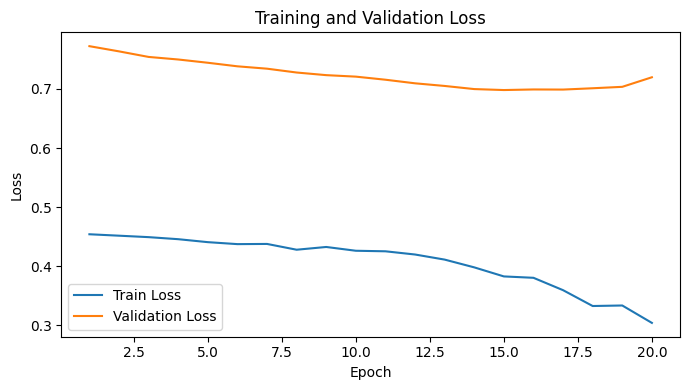

In [46]:
import matplotlib.pyplot as plt
history = result["history"]
epochs = range(1, len(history["train_loss"]) + 1)
plt.figure(figsize=(7,4))
plt.plot(epochs,history["train_loss"],label="Train Loss")
plt.plot(epochs,history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
print("Raw windows:")
for label in range(N_CLASSES):
    print(f"{CLASS_NAMES[label]}: {sum(y==label for y in y_raw)}")

print("\nRaw files:")
for label in range(N_CLASSES):
    files=set(file_paths_raw[i] for i,y in enumerate(y_raw) if y==label)
    print(f"{CLASS_NAMES[label]}: {len(files)}")

Raw windows:
calm_speech: 98
distress: 418

Raw files:
calm_speech: 96
distress: 336


In [48]:
# # Testing only cell
# if not MODEL_PATH.exists():
#     raise FileNotFoundError(f"Model file not found: {MODEL_PATH}")

# model = RNNClassifier(
#     n_features=N_FEATURES,
#     hidden_size=HIDDEN_SIZE,
#     num_layers=NUM_LAYERS,
#     n_classes=N_CLASSES,
#     dropout=DROPOUT,
#     bidirectional=BIDIRECTIONAL,
#     input_dropout=INPUT_DROPOUT,
# ).to(DEVICE)

# checkpoint = torch.load(
#     MODEL_PATH,
#     map_location=DEVICE,
#     weights_only=True,
# )

# model.load_state_dict(checkpoint)
# model.eval()

# print("Model loaded successfully!")
# print(f"Loaded from: {MODEL_PATH}")
# print(f"Device: {DEVICE}")

In [49]:
def segment_and_extract(signal, sr, label):
    signal = bandpass_filter(
        signal,
        sr,
        BANDPASS_LOW_HZ,
        BANDPASS_HIGH_HZ,
    )
    win_len = int(WINDOW_SEC * sr)
    hop_len = int(HOP_SEC * sr)
    if len(signal) < win_len:
        signal = np.pad(
            signal,
            (0, win_len - len(signal)),
            mode="constant",
        )
    samples = []
    for start in range(
        0,
        len(signal) - win_len + 1,
        hop_len,
    ):
        window = signal[start:start + win_len]
        features = extract_features(
            window,
            sr,
        )
        if features.shape[0] > 0:
            samples.append(
                (features, label)
            )

    return samples

In [50]:
from collections import Counter

def predict_with_fold_ensemble(fpath):
    signal = load_one_file(fpath, SENSOR_SAMPLE_RATE)

    samples = segment_and_extract(
        signal,
        SENSOR_SAMPLE_RATE,
        label=0,
    )

    if not samples:
        raise ValueError(f"No windows extracted from {fpath.name}")

    features_list = [feat for feat, _ in samples]

    ensemble_probs = np.zeros(N_CLASSES, dtype=np.float32)

    for fold_index in range(len(fold_models)):
        seq_len = fold_seq_lens[fold_index]
        scaler = fold_scalers[fold_index]
        model = fold_models[fold_index]

        X_fold = np.array(
            [pad_or_trim(feat, seq_len) for feat in features_list],
            dtype=np.float32,
        )

        n_samples, n_steps, n_features = X_fold.shape

        X_fold = scaler.transform(
            X_fold.reshape(-1, n_features)
        ).reshape(
            n_samples,
            n_steps,
            n_features,
        ).astype(np.float32)
        loader = DataLoader(
            VibrationDataset(
                X_fold,
                np.zeros(len(X_fold), dtype=np.int64),
            ),
            batch_size=BATCH_SIZE,
            shuffle=False,
        )

        model.eval()
        fold_probs = []

        with torch.no_grad():
            for xb, _ in loader:
                logits, _ = model(xb.to(DEVICE))

                fold_probs.append(
                    torch.softmax(logits, dim=1).cpu().numpy()
                )

        fold_mean = np.concatenate(fold_probs).mean(axis=0)

        ensemble_probs += fold_mean / len(fold_models)

    predicted_label = int(np.argmax(ensemble_probs))

    return predicted_label, ensemble_probs, len(features_list)


def predict_with_fold_ensemble_timeline(fpath):
    signal = load_one_file(fpath, SENSOR_SAMPLE_RATE)

    samples = segment_and_extract(
        signal,
        SENSOR_SAMPLE_RATE,
        label=0,
    )

    if not samples:
        raise ValueError(f"No windows extracted from {fpath.name}")

    features_list = [feat for feat, _ in samples]

    all_window_probs = []

    for fold_index in range(len(fold_models)):
        seq_len = fold_seq_lens[fold_index]
        scaler = fold_scalers[fold_index]
        model = fold_models[fold_index]

        X_fold = np.array(
            [pad_or_trim(feat, seq_len) for feat in features_list],
            dtype=np.float32,
        )

        n_samples, n_steps, n_features = X_fold.shape

        X_fold = scaler.transform(
            X_fold.reshape(-1, n_features)
        ).reshape(
            n_samples,
            n_steps,
            n_features,
        ).astype(np.float32)

        loader = DataLoader(
            VibrationDataset(
                X_fold,
                np.zeros(len(X_fold), dtype=np.int64),
            ),
            batch_size=BATCH_SIZE,
            shuffle=False,
        )

        model.eval()
        fold_probs = []

        with torch.no_grad():
            for xb, _ in loader:
                logits, _ = model(xb.to(DEVICE))

                fold_probs.append(
                    torch.softmax(logits, dim=1).cpu().numpy()
                )

        all_window_probs.append(
            np.concatenate(fold_probs, axis=0)
        )

    ensemble_window_probs = np.mean(
        np.stack(all_window_probs, axis=0),
        axis=0,
    )

    window_predictions = np.argmax(
        ensemble_window_probs,
        axis=1,
    )

    return (
        signal,
        ensemble_window_probs,
        window_predictions,
        len(features_list),
    )

In [51]:
y_true = []
y_pred = []
prediction_rows = []

for class_name, true_label in {
    "calm_speech": 0,
    "distress": 1,
}.items():

    folder = SENSOR_DATA_DIR / class_name

    files = sorted([
        f for f in list(folder.glob("*.npy")) + list(folder.glob("*.wav"))
        if f.stem.split("_")[0] in TEST_ACTORS
    ])

    if class_name == "distress":
        files = [
            f for f in files
            if "_ANG_" in f.name
            or "_FEA_" in f.name
            or "_SAD_" in f.name
        ]

    print(f"{class_name}: {len(files)} held-out files")

    for fpath in files:
        pred_label, probs, n_windows = predict_with_fold_ensemble(fpath)

        y_true.append(true_label)
        y_pred.append(pred_label)

        prediction_rows.append({
            "filename": fpath.name,
            "true_label": CLASS_NAMES[true_label],
            "predicted_label": CLASS_NAMES[pred_label],
            "prob_calm_speech": float(probs[0]),
            "prob_distress": float(probs[1]),
            "n_windows": n_windows,
            "correct": pred_label == true_label,
        })

calm_speech: 48 held-out files
distress: 168 held-out files


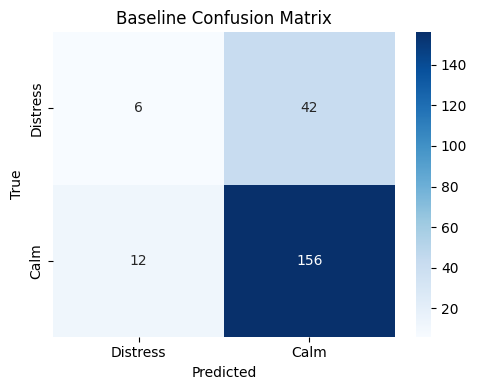

In [52]:
cm=np.array([
    [
        sum(t==0 and p==0 for t,p in zip(y_true,y_pred)),
        sum(t==0 and p==1 for t,p in zip(y_true,y_pred)),
    ],
    [
        sum(t==1 and p==0 for t,p in zip(y_true,y_pred)),
        sum(t==1 and p==1 for t,p in zip(y_true,y_pred)),
    ],
])
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Distress","Calm"],
    yticklabels=["Distress","Calm"],
)
plt.title("Baseline Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
save_path=OUTPUT_DIR/"confusion_matrix_baseline.png"
plt.savefig(save_path,dpi=150)
plt.show()

In [53]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score,f1_score,recall_score,classification_report,confusion_matrix,balanced_accuracy_score,roc_auc_score

accuracy=accuracy_score(y_true,y_pred)
macro_f1=f1_score(y_true,y_pred,labels=[0,1],average="macro",zero_division=0)
macro_recall=recall_score(y_true,y_pred,labels=[0,1],average="macro",zero_division=0)
balanced_accuracy=balanced_accuracy_score(y_true,y_pred)

cm=confusion_matrix(y_true,y_pred,labels=[0,1])

sensitivities=[]
specificities=[]

for i in [0,1]:
    tp=cm[i,i]
    fn=cm[i,:].sum()-tp
    fp=cm[:,i].sum()-tp
    tn=cm.sum()-tp-fn-fp
    sensitivities.append(tp/(tp+fn) if tp+fn>0 else 0.0)
    specificities.append(tn/(tn+fp) if tn+fp>0 else 0.0)

sensitivity=np.mean(sensitivities)
specificity=np.mean(specificities)

pred_df=pd.DataFrame(prediction_rows)
y_scores=pred_df[["prob_calm_speech","prob_distress"]].to_numpy()

auc_values=[]
y_true_array=np.array(y_true)

for i in [0,1,2]:
    y_binary=(y_true_array==i).astype(int)
    if len(np.unique(y_binary))==2:
        auc_values.append(roc_auc_score(y_binary,y_scores[:,i]))

auc_roc=np.mean(auc_values) if auc_values else 0.0

print(f"Files evaluated : {len(y_true)}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")
print(f"Sensitivity     : {sensitivity:.4f}")
print(f"Specificity     : {specificity:.4f}")
print(f"Balanced Acc.   : {balanced_accuracy:.4f}")
print(f"AUC-ROC         : {auc_roc:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true,y_pred,labels=[0,1],target_names=["Calm speech","Distress"],zero_division=0,digits=4))

print("\nConfusion Matrix:")
print(cm)

Files evaluated : 216
Accuracy        : 0.7500
Macro F1        : 0.5171
Macro Recall    : 0.5268
Sensitivity     : 0.5268
Specificity     : 0.5268
Balanced Acc.   : 0.5268
AUC-ROC         : 0.6037

Classification Report:

              precision    recall  f1-score   support

 Calm speech     0.3333    0.1250    0.1818        48
    Distress     0.7879    0.9286    0.8525       168

    accuracy                         0.7500       216
   macro avg     0.5606    0.5268    0.5171       216
weighted avg     0.6869    0.7500    0.7034       216


Confusion Matrix:
[[  6  42]
 [ 12 156]]


In [54]:
print("Best validation F1:", result["best_val_f1"])
history = result["history"]
print("Epoch | Train Loss | Val Loss | Train Acc | Val Acc")
print("-" * 72)

for i in range(len(history["train_loss"])):
    print(
        f"{i+1:5d} | "
        f"{history['train_loss'][i]:10.4f} | "
        f"{history['val_loss'][i]:13.2f} | "
        f"{history['train_acc'][i]:9.4f} | "
        f"{history['val_acc'][i]:7.4f} | "
    )

Best validation F1: 0.7436582109479306
Epoch | Train Loss | Val Loss | Train Acc | Val Acc
------------------------------------------------------------------------
    1 |     0.4541 |          0.77 |    0.6005 |  0.5938 | 
    2 |     0.4517 |          0.76 |    0.6572 |  0.7812 | 
    3 |     0.4492 |          0.75 |    0.7861 |  0.8125 | 
    4 |     0.4458 |          0.75 |    0.7887 |  0.8125 | 
    5 |     0.4407 |          0.74 |    0.8015 |  0.8125 | 
    6 |     0.4374 |          0.74 |    0.8093 |  0.8125 | 
    7 |     0.4377 |          0.73 |    0.8093 |  0.8125 | 
    8 |     0.4279 |          0.73 |    0.8093 |  0.8125 | 
    9 |     0.4326 |          0.72 |    0.8093 |  0.8125 | 
   10 |     0.4262 |          0.72 |    0.8119 |  0.8438 | 
   11 |     0.4253 |          0.72 |    0.8041 |  0.8438 | 
   12 |     0.4198 |          0.71 |    0.8196 |  0.8594 | 
   13 |     0.4112 |          0.70 |    0.8273 |  0.8438 | 
   14 |     0.3981 |          0.70 |    0.8376 |  0.8281